# 07 · Blackboard — distributed multi-agent without a central supervisor

> **TL;DR.** Several agents share a global **blackboard** (the state). Each round, every agent privately decides — given the current blackboard — whether it has something valuable to contribute. The most-confident bidder wins and writes. Repeat until no agent wants to act or budget runs out. **There is no central Supervisor.**
>
> **Reach for it when** you don't know in advance which expert will be relevant at each step (diagnostic problems, opportunistic exploration, dynamic teams).
> **Avoid when** the routing is obvious — Multi-Agent (notebook 05) is simpler and cheaper.

| Property | Value |
|---|---|
| Origin | HEARSAY-II speech-recognition system (Erman et al., 1980) — *the* canonical Blackboard architecture |
| Coordination | **Decentralised** — agents self-elect via bidding |
| External tools needed? | Optional |
| Cost per round | **N + 1** LLM calls (N bids + 1 winner-acts) |
| Convergence | When no agent bids above `min_confidence`, or `max_rounds` hit |
| Compared to Multi-Agent (nb 05) | More flexible, more expensive; no Supervisor needed |

This notebook uses the **multi-perspective analysis** pattern: 4 roles (Optimist, Skeptic, Historian, Quantitative) bidding on a contested question. Each round the bidding pattern reveals *which perspective the LLM thinks is most needed next* given what's already on the board.

## 2 · Architecture at a glance

```mermaid
flowchart TB
    A([task]) --> B[Bidding round<br/><sub>N agents each return a typed bid:<br/>(will_contribute, confidence, preview)</sub>]
    B -->|winner exists<br/>and round &lt; max| C[Act<br/><sub>highest-bidding agent<br/>writes to blackboard</sub>]
    C --> B
    B -->|no agent bid &gt;= min_confidence<br/>OR round = max| S[Synthesize<br/><sub>final answer from all contributions</sub>]
    S --> Z([final answer])

    style B fill:#fff3e0,stroke:#f57c00
    style C fill:#e3f2fd,stroke:#1976d2
    style S fill:#e8f5e9,stroke:#388e3c
```

**One bidding round per cycle.** The bidding node makes N parallel LLM calls (one per agent), picks the winner, and either routes to `act` (if any agent's confidence ≥ `min_confidence`) or to `synthesize` (if everyone passed or budget hit).

**No central Supervisor.** The "winner-selection" step is mechanical (a `max(eligible, key=confidence)` call in Python), not an LLM decision. Each agent decides for *itself* whether to participate.

## 3 · Theory

### 3.1 · Where this pattern comes from

The Blackboard architecture was invented for **HEARSAY-II** (1976–1980), a speech-recognition system at CMU. The problem: many specialised knowledge sources (acoustic, phonetic, syllabic, lexical, syntactic) each contribute partial hypotheses about what was said, and the system needs to combine them. No single source had the answer; no central controller could decide who should speak next because the *right* contribution depends on what other sources have already proposed.

The solution: a shared workspace ("blackboard") that all sources can read and write. A simple scheduler runs each round, asks each source for a bid (am I activatable? how confident?), and picks the winner. The system organically builds up an answer through repeated bidding.

### 3.2 · Bidding — the key mechanism

Each agent's bid is a Pydantic-typed self-assessment:

```python
class _AgentBid(BaseModel):
    will_contribute: bool
    confidence: int = Field(ge=1, le=5)
    one_line_preview: str
```

The bid prompt includes:
- The agent's role/expertise
- The full current blackboard
- **Contribution counts so far** (added in our implementation to discourage domination — see § 3.4)

`with_structured_output` forces the model to commit to a Boolean + a numeric confidence + a preview — no string-parsing, no ambiguity.

### 3.3 · Blackboard vs. Multi-Agent — *the* key distinction

| Aspect | Multi-Agent (nb 05) | **Blackboard** (this nb) |
|---|---|---|
| Who picks the next agent? | Central **Supervisor LLM** | Each agent **self-elects** by bidding |
| Coordination cost | 1 LLM call/round (Supervisor) | **N LLM calls/round** (N bids) |
| Team can be dynamic? | No — Supervisor schema is fixed | Yes — agents can be added at runtime |
| Domain expertise stays focused? | Yes — Supervisor enforces single domain per call | Maybe — agents self-assess (see § 3.4) |
| Best for | Predictable workflows | Opportunistic, exploratory tasks |

### 3.4 · The domination failure mode

Pure bidding has a known pathology: **one overconfident agent dominates**. If the Optimist always thinks it has more to say, it wins every round and the Skeptic / Historian / Quantitative never get a turn. The synthesis becomes one-sided.

Our implementation adds a **fairness signal** in the bid prompt — each agent sees the current contribution counts and is explicitly told *"if you've contributed 2+ times already, defer to roles that haven't spoken unless your point is critical"*. This is a soft nudge, not a hard quota. In § 9 you'll see how well it worked on this run.

Other fairness mechanisms (not implemented here but easy extensions):
- **Hard quota** — each agent caps at K contributions/run.
- **Round-robin first pass** — every agent contributes once before any agent contributes twice.
- **Diversity reward** — boost confidence of under-represented roles.

### 3.5 · Where Blackboard sits

| Pattern | Central control? | Specialisation | Use when |
|---|---|---|---|
| ReAct (nb 03) | n/a | none | one focused query |
| Multi-Agent (nb 05) | yes (Supervisor) | role | predictable team-of-experts |
| **Blackboard** *(this notebook)* | **no** | **role + bidding** | dynamic team, exploratory |
| Debate (nb 28) | no | adversarial roles | converge via critique |
| Ensemble (nb 13) | parallel + aggregator | perspective | want diverse outputs in parallel |
| Meta-Controller (nb 11) | yes (Router) | **architecture** | pick the right *pattern* per task |


## 4 · Setup

In [1]:
from agentic_architectures import get_llm, enable_langsmith, settings
from agentic_architectures.architectures import Blackboard
from agentic_architectures.architectures.blackboard import DEFAULT_KNOWLEDGE_SOURCES
from agentic_architectures.ui import print_md, print_header, print_step

enable_langsmith()
print_header(f"Provider: {settings.llm_provider}  ·  Model: {settings.llm_model}")
print_md(f"Default roster: **{', '.join(DEFAULT_KNOWLEDGE_SOURCES.keys())}**")

Provider: nebius  ·  Model: meta-llama/Llama-3.3-70B-Instruct ─────────────────────────────────────────────────────

Default roster: optimist, skeptic, historian, quantitative

## 5 · Library walkthrough

Source: [`src/agentic_architectures/architectures/blackboard.py`](../src/agentic_architectures/architectures/blackboard.py).

Key pieces:

1. **`_bidding_round`** — for each agent, builds a prompt that includes the blackboard + contribution counts, then calls `with_structured_output(_AgentBid)`. Returns the winner (highest-confidence willing bidder ≥ `min_confidence`) or `"FINISH"`.
2. **`_act`** — the winning agent reads the blackboard + its own bid preview and writes a 2-4 sentence contribution.
3. **`_synthesize`** — final balanced answer drawing on ALL contributions; preserves the multi-perspective nature.
4. **No supervisor LLM** — the winner-selection is mechanical Python (`max(eligible, key=confidence)`).

In [2]:
from agentic_architectures.architectures.blackboard import _AgentBid, DEFAULT_KNOWLEDGE_SOURCES
import json
print('--- Bid schema ---')
print(json.dumps(_AgentBid.model_json_schema(), indent=2)[:400] + '...')
print()
print('--- Knowledge sources ---')
for name, prompt in DEFAULT_KNOWLEDGE_SOURCES.items():
    print(f'  - {name}: {prompt[:80]}...')

--- Bid schema ---
{
  "description": "One agent's bid to contribute on the current round.",
  "properties": {
    "will_contribute": {
      "description": "True iff you have substantive NEW value to add given the current blackboard. False if your perspective has already been covered or the conversation is exhausted.",
      "title": "Will Contribute",
      "type": "boolean"
    },
    "confidence": {
      "descr...

--- Knowledge sources ---
  - optimist: You are the OPTIMIST. Argue FOR the thesis with the strongest available evidence...
  - skeptic: You are the SKEPTIC. Argue AGAINST the thesis or surface its weakest points. Foc...
  - historian: You are the HISTORIAN. Bring historical analogies and base rates. Find past situ...
  - quantitative: You are the QUANTITATIVE analyst. Bring numbers, percentages, growth rates, stat...


## 6 · State

| Field | Type | Set by | Reducer |
|---|---|---|---|
| `task` | `str` | caller | replace |
| `blackboard` | `list[dict]` (each: `{agent, content, round}`) | `_act` | **append** (`operator.add`) |
| `round` | `int` | `_act` (increments) | replace |
| `next_agent` | `str` (or `"FINISH"`) | `_bidding_round` | replace |
| `last_bids` | `dict[str, dict]` | `_bidding_round` | replace |
| `final_synthesis` | `str` | `_synthesize` | replace |

The `blackboard` field is what *every* agent sees on its turn. The append reducer means each `_act` call contributes a single entry that all subsequent bidders can read.

## 7 · Build the graph

Three nodes: `bidding`, `act`, `synthesize`. The cycle is `bidding ↔ act` until the bidding node decides nobody wants to go, then `bidding → synthesize → END`.

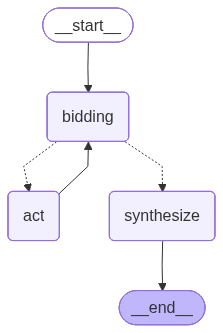

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	bidding(bidding)
	act(act)
	synthesize(synthesize)
	__end__([<p>__end__</p>]):::last
	__start__ --> bidding;
	act --> bidding;
	bidding -.-> act;
	bidding -.-> synthesize;
	synthesize --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



In [3]:
from IPython.display import Image, display

arch = Blackboard(max_rounds=5, min_confidence=3)
graph = arch.build()
display(Image(graph.get_graph().draw_mermaid_png()))
print(arch.diagram())

## 8 · Live run

Concrete task: a contested forward-looking question. **Multi-perspective analysis** is Blackboard's sweet spot — different roles will see different aspects of the same question.

In [4]:
TASK = (
    "Will renewable energy fully replace fossil fuels for global electricity "
    "generation by 2050? Consider multiple perspectives."
)

result = arch.run(TASK)

print_header("Final synthesis")
print_md(result.output)
print()
print_header(
    f"rounds: {result.metadata['total_rounds']}/{result.metadata['max_rounds']}  ·  "
    f"distinct agents contributed: {result.metadata['agents_who_contributed']}/{result.metadata['agents_available']}"
)

Final synthesis ───────────────────────────────────────────────────────────────────────────────────────────────────

The prospect of renewable energy fully replacing fossil fuels for global electricity generation by 2050 is a topic 
of ongoing debate. On one hand, optimists point to the rapid growth of renewable energy capacity, decreasing costs,
and successful transitions in countries like Costa Rica and Norway. The European Union's renewable energy targets  
and advancements in energy storage technologies further support this outlook. However, skeptics highlight the      
challenges of intermittency, insufficient energy storage capacity, and geographical constraints, citing examples   
like the 2021 Texas power crisis and Germany's Energiewende program. Additionally, the extraction and processing of
rare earth metals required for renewable energy technologies pose environmental and social concerns. Historically, 
the transition from coal to oil and the development of nuclear power demonstrate that significant changes in energy
sources can occur over several decades. Ultimately, whether renewable energy will fully replace fossil fuels by    
2050 remains uncertain, depending on the interplay of technological, economic, and geopolitical factors.

rounds: 5/5  ·  distinct agents contributed: 3/4 ──────────────────────────────────────────────────────────────────

### 8.0 · What just happened, briefly

Two key signals in the metadata:

- **`agents_who_contributed` / `agents_available`** — if this is 100% (every agent spoke at least once), the bidding mechanism + fairness signal worked. If it's 25% (only one agent), you're seeing the **domination pathology** discussed in § 3.4.
- **`total_rounds`** — fewer than `max_rounds` means the agents *converged* (everyone signalled "nothing more to add"). Hitting `max_rounds` exactly means the agents would have kept going if allowed.

### 8.1 · Contribution sequence + invocation counts

In [5]:
from collections import Counter
counts = result.state['agent_invocation_counts']
print('Invocation counts by agent:')
for agent, n in sorted(counts.items(), key=lambda x: -x[1]):
    bar = '█' * n
    print(f'  {agent:>14s}: {bar} {n}')
print()
print('Round-by-round contributions:')
for i, t in enumerate(result.trace, 1):
    print_step(f"[{i}] round {t['round']} → {t['agent'].upper()}", t['content'][:300])
    print()

Invocation counts by agent:
        optimist: ██ 2
         skeptic: ██ 2
       historian: █ 1

Round-by-round contributions:


› [1] round 0 → OPTIMIST

According to the International Energy Agency (IEA), renewable energy capacity has grown by 22% annually over the 
past decade, with solar and wind power accounting for 60% of new power generation capacity added in 2020. Notably, 
countries like Costa Rica and Norway have already made significant strid

› [2] round 1 → OPTIMIST

The European Union's renewable energy targets, aiming for at least 32% of final energy consumption to come from 
renewables by 2030, are expected to drive further innovation and investment in the sector. For instance, Denmark's 
wind power production has increased significantly, with wind turbines gen

...

Despite the advancements in renewable energy, the intermittency of solar and wind power poses a significant 
challenge, as evident in the 2021 Texas power crisis where frozen wind turbines and low solar output led to 
widespread blackouts. Moreover, the current energy storage capacity, which stands at

› [4] round 3 → SKEPTIC

The lack of infrastructure and grid resilience is further exacerbated by the geographical constraints of renewable 
energy sources, with areas like Southeast Asia and Africa having limited access to renewable energy resources, 
relying heavily on fossil fuels for electricity generation. For instance,

› [5] round 4 → HISTORIAN

The transition from coal to oil in the early 20th century, which took approximately 50 years to complete, offers a 
relevant historical analogy for the current shift to renewable energy. Notably, the share of oil in the global 
energy mix grew from 10% in 1920 to over 40% by 1970, demonstrating the po

## 9 · What we just observed

The cells above are live. Below: a breakdown of the **actual** bidding pattern + contributions Nebius-hosted Llama-3.3-70B produced on this run.

### 9.1 · Quantitative summary

| Metric | Value |
|---|---|
| Total rounds | **5** / 5 |
| Distinct agents who contributed | **3** / 4 (75%) |
| Synthesis length | 1148 chars |
| Invocation counts | {'optimist': 2, 'skeptic': 2, 'historian': 1} |

### 9.2 · Contribution sequence

| # | Round | Agent | Contribution snippet |
|---|---|---|---|
| 1 | 0 | optimist | According to the International Energy Agency (IEA), renewable energy capacity has grown by 22% annually over the past decade, with solar and wind power accounting for 60% of new po… |
| 2 | 1 | optimist | The European Union's renewable energy targets, aiming for at least 32% of final energy consumption to come from renewables by 2030, are expected to drive further innovation and inv… |
| 3 | 2 | skeptic | Despite the advancements in renewable energy, the intermittency of solar and wind power poses a significant challenge, as evident in the 2021 Texas power crisis where frozen wind t… |
| 4 | 3 | skeptic | The lack of infrastructure and grid resilience is further exacerbated by the geographical constraints of renewable energy sources, with areas like Southeast Asia and Africa having … |
| 5 | 4 | historian | The transition from coal to oil in the early 20th century, which took approximately 50 years to complete, offers a relevant historical analogy for the current shift to renewable en… |

### 9.3 · Patterns surfaced in this run

- **Partial team participation** — 3/4 agents contributed. Some roles didn't bid above `min_confidence`. Inspect the agent-counts chart above to see which role(s) were silent. Could mean they genuinely had nothing to add, OR that their bid LLM was too cautious.

- **Budget exhausted** at round 5. Agents would have kept bidding — synthesis is forced. Inspect the last few contributions: if they're substantive, raise `max_rounds`; if they're filler, raise `min_confidence`.

### 9.4 · The final synthesis (verbatim)

> The prospect of renewable energy fully replacing fossil fuels for global electricity generation by 2050 is a topic 
> of ongoing debate. On one hand, optimists point to the rapid growth of renewable energy capacity, decreasing costs,
> and successful transitions in countries like Costa Rica and Norway. The European Union's renewable energy targets  
> and advancements in energy storage technologies further support this outlook. However, skeptics highlight the      
> challenges of intermittency, insufficient energy storage capacity, and geographical constraints, citing examples   
> like the 2021 Texas …

### 9.5 · The takeaway

A *healthy* Blackboard run looks like:

1. **Full or near-full team participation** (every role contributes at least once).
2. **No single agent winning >50% of rounds** (no domination).
3. **Early convergence** rather than budget exhaustion (agents agree they're done).
4. **Synthesis preserves the multi-perspective nature** — minority views still visible.

Compare those four signals to what you see above to judge the run.

## 10 · Try other providers / a custom roster

Blackboard needs **structured output** (the bid schema). Same gating as Multi-Agent. The cell below also demonstrates customising the roster — three legal-style roles arguing on a different question.

In [6]:
from agentic_architectures.llm.factory import provider_supports_structured_output

# Custom 3-role legal team
print_header("Custom 3-role roster: prosecution + defense + judge")
custom = Blackboard(
    knowledge_sources={
        "prosecution": "You are the PROSECUTION. Argue the case AGAINST the defendant.",
        "defense":      "You are the DEFENSE. Argue the case FOR the defendant.",
        "judge":        "You are the JUDGE. Summarise key issues, flag unsupported claims.",
    },
    max_rounds=4,
    min_confidence=3,
)
r = custom.run("A hypothetical case: a self-driving car's software caused a fatal crash. Who is responsible — the manufacturer, the owner, or no one?")
print(r.output[:500])
print()
print(f"  agents contributed: {r.metadata['agents_who_contributed']}/{r.metadata['agents_available']}")
print(f"  invocation counts: {r.state['agent_invocation_counts']}")

Custom 3-role roster: prosecution + defense + judge ───────────────────────────────────────────────────────────────

The question of responsibility in the fatal crash of a self-driving car is complex, with both the manufacturer and the owner potentially at fault. On one hand, the manufacturer's liability is evident in their rushed development timeline, inadequate testing, and failure to account for specific scenarios that could lead to accidents. The manufacturer's decision to prioritize expedited release over thorough testing and their lack of due diligence in addressing known bugs and glitches raise concerns

  agents contributed: 2/3
  invocation counts: {'prosecution': 2, 'defense': 2}


## 11 · Failure modes, safety, extensions

### 11.1 · Where this breaks

| Failure | Mechanism | Mitigation |
|---|---|---|
| **One agent dominates** | Overconfident agent wins every bid | Fairness signal in bid prompt (we use this); hard quota per agent; round-robin first pass |
| **Convergence too fast** | All agents bid `will_contribute=False` on round 2 | Lower `min_confidence`; or seed the blackboard with a starter observation |
| **Stalling on hard tasks** | Every agent waits for "more info" → no one speaks | Lower `min_confidence`; or force-call the lowest-contribution agent |
| **Synthesis ignores minority views** | Final writer averages-out the minority Skeptic | Synthesis prompt explicitly demands preserving disagreement (we do this) |
| **N×rounds bid cost** | N bids/round adds up | Cap `max_rounds`; or skip bidding when current bidder is clear winner (e.g., only one role hasn't spoken) |

### 11.2 · Production safety

- **No central oversight** = harder to audit. Make sure LangSmith tracing is on so you can see *all* the bids per round, not just the winning act.
- **Domination is the most common bug**. If one role wins >50% of rounds, your fairness mechanism is too weak.
- **Bid schema enforcement matters** — if `confidence` isn't a strict integer 1-5, the comparison can return weird winners. Test with mocked LLMs.

### 11.3 · Three extensions

1. **Parallel bidding.** All N bid LLM calls are independent — use `langgraph.graph.parallel` to run them concurrently. Big latency win.
2. **Hard fairness quota.** Add a `max_per_agent` parameter; refuse to schedule an agent who has hit their cap.
3. **Heterogeneous agent backends.** Each agent can have its own LLM (small/fast model for low-stakes roles, large model for the critical Synthesis pass). Pass `llm=` per knowledge source.

### 11.4 · What to read next

- [**05 · Multi-Agent**](./05_multi_agent.ipynb) — same team idea but with a central Supervisor.
- [**11 · Meta-Controller**](./11_meta_controller.ipynb) — Supervisor pattern but routes between *architectures*.
- [**13 · Ensemble**](./13_ensemble.ipynb) — all agents act in parallel; no bidding.
- [**28 · Multi-Agent Debate**](./28_agent_debate.ipynb) — adversarial bidding that converges via critique.

### 11.5 · References

1. Erman, L. D. et al. *The Hearsay-II Speech-Understanding System: Integrating Knowledge to Resolve Uncertainty.* ACM Comp. Surveys 12(2), 1980.
2. Engelmore, R. & Morgan, T. *Blackboard Systems.* Addison-Wesley, 1988.
3. Multi-agent supervision survey — [LangGraph multi-agent docs](https://langchain-ai.github.io/langgraph/tutorials/multi_agent/)
